In [1]:
# ============================================
# Dropout Prediction using SVM, ANN, RF, LR, XGBoost with SMOTE
# Updated with
# + StratifiedKFold Cross-Validation
# + AUC-ROC for all models
# by Faris
# ============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report, roc_auc_score, roc_curve)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
# --------------------------------------------
# Load dataset
# --------------------------------------------
df = pd.read_csv("student_dropout_dataset.csv")
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

# --------------------------------------------
# Separate target
# --------------------------------------------
y = df['dropout_status']
X = df.drop(columns=['dropout_status', 'student_id'], errors='ignore')

Dataset loaded successfully!
Dataset shape: (5000, 26)


In [4]:
# --------------------------------------------
# Remove leakage columns
# --------------------------------------------
leakage_cols = [
    'credits_completed',
    'subject_failure_count',
    'counseling_sessions_attended',
    'attendance_rate'                # attendance_rate is the main cause for data leakage
]
X = X.drop(columns=[c for c in leakage_cols if c in X.columns])
print(f"\nFeatures after leakage removal: {X.shape[1]}")
print(f"Features used: {list(X.columns)}")


Features after leakage removal: 20
Features used: ['age', 'gender', 'socioeconomic_status', 'parental_education_level', 'family_background', 'first_generation_student', 'gpa', 'previous_academic_performance', 'course_load', 'scholarship_status', 'class_participation_score', 'assignment_submission_rate', 'quiz_completion_rate', 'time_spent_on_learning_platform', 'login_frequency', 'engagement_score', 'learning_style', 'motivation_level', 'peer_interaction_score', 'stress_level']


In [5]:
# --------------------------------------------
# One-hot encode categorical features
# --------------------------------------------
X = pd.get_dummies(X, drop_first=True)
print(f"Features after encoding: {X.shape[1]}")

# --------------------------------------------
# Train/Test split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# --------------------------------------------
# Apply SMOTE to training data only
# --------------------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

# --------------------------------------------
# Standardize features for SVM, ANN, LR
# --------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

# --------------------------------------------
# StratifiedKFold setup (5-fold)
# --------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*60)
print("STRATIFIED K-FOLD CROSS-VALIDATION (5-Fold)")
print("="*60)
print("Note: SMOTE applied inside each fold to prevent CV leakage")

Features after encoding: 30

Train size: 4000 | Test size: 1000
After SMOTE: {0: 3027, 1: 3027}

STRATIFIED K-FOLD CROSS-VALIDATION (5-Fold)
Note: SMOTE applied inside each fold to prevent CV leakage


In [6]:
# ── Helper: print CV results ──────────────────────────────────
def print_cv_results(name, acc_scores, f1_scores, auc_scores):
    print(f"\n  Accuracy : {acc_scores.mean()*100:.2f}% ± {acc_scores.std()*100:.2f}%")
    print(f"  F1 Score : {f1_scores.mean()*100:.2f}% ± {f1_scores.std()*100:.2f}%")
    print(f"  AUC-ROC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")


# ── Helper: print holdout test results ───────────────────────
def print_test_results(name, y_true, y_pred, y_prob=None):
    print(f"\n=== {name} — Holdout Test Set ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"F1 Score : {f1_score(y_true, y_pred)*100:.2f}%")
    if y_prob is not None:
        print(f"AUC-ROC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred))

In [7]:

# ============================================
# 1 — SVM Classifier
# ============================================
print("\n" + "-"*60)
print("1. SVM")
print("-"*60)

# CV pipeline: SMOTE inside each fold
svm_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', class_weight='balanced',
                  probability=True, random_state=42))
])
svm_acc = cross_val_score(svm_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
svm_f1  = cross_val_score(svm_pipeline, X_train, y_train, cv=cv, scoring='f1')
svm_auc = cross_val_score(svm_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print_cv_results("SVM", svm_acc, svm_f1, svm_auc)

# Holdout test
svm_model = SVC(kernel='rbf', class_weight='balanced',
                probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train_res)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
print_test_results("SVM", y_test, y_pred_svm, y_prob_svm)


------------------------------------------------------------
1. SVM
------------------------------------------------------------

  Accuracy : 79.68% ± 1.53%
  F1 Score : 52.04% ± 3.51%
  AUC-ROC  : 0.8068 ± 0.0261

=== SVM — Holdout Test Set ===
Accuracy : 79.90%
F1 Score : 53.36%
AUC-ROC  : 0.8314
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       757
           1       0.61      0.47      0.53       243

    accuracy                           0.80      1000
   macro avg       0.73      0.69      0.70      1000
weighted avg       0.79      0.80      0.79      1000



In [8]:
# ============================================
# 2 — ANN (MLPClassifier)
# ============================================
print("\n" + "-"*60)
print("2. ANN (MLP)")
print("-"*60)

ann_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])
ann_acc = cross_val_score(ann_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
ann_f1  = cross_val_score(ann_pipeline, X_train, y_train, cv=cv, scoring='f1')
ann_auc = cross_val_score(ann_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print_cv_results("ANN", ann_acc, ann_f1, ann_auc)

# Holdout test — use improved ANN settings
ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
ann_model.fit(X_train_scaled, y_train_res)
y_pred_ann = ann_model.predict(X_test_scaled)
y_prob_ann = ann_model.predict_proba(X_test_scaled)[:, 1]
print_test_results("ANN", y_test, y_pred_ann, y_prob_ann)


------------------------------------------------------------
2. ANN (MLP)
------------------------------------------------------------

  Accuracy : 77.30% ± 1.29%
  F1 Score : 51.16% ± 2.72%
  AUC-ROC  : 0.7896 ± 0.0182

=== ANN — Holdout Test Set ===
Accuracy : 78.10%
F1 Score : 51.01%
AUC-ROC  : 0.8055
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       757
           1       0.56      0.47      0.51       243

    accuracy                           0.78      1000
   macro avg       0.70      0.68      0.68      1000
weighted avg       0.77      0.78      0.77      1000



In [9]:
# ============================================
# 3 — Random Forest
# ============================================
print("\n" + "-"*60)
print("3. Random Forest")
print("-"*60)

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200, max_depth=None,
        class_weight='balanced', random_state=42
    ))
])
rf_acc = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
rf_f1  = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1')
rf_auc = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print_cv_results("Random Forest", rf_acc, rf_f1, rf_auc)

# Holdout test
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', random_state=42
)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
print_test_results("Random Forest", y_test, y_pred_rf, y_prob_rf)


------------------------------------------------------------
3. Random Forest
------------------------------------------------------------

  Accuracy : 80.55% ± 1.43%
  F1 Score : 57.73% ± 3.39%
  AUC-ROC  : 0.8562 ± 0.0182

=== Random Forest — Holdout Test Set ===
Accuracy : 80.80%
F1 Score : 58.62%
AUC-ROC  : 0.8433
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       757
           1       0.62      0.56      0.59       243

    accuracy                           0.81      1000
   macro avg       0.74      0.72      0.73      1000
weighted avg       0.80      0.81      0.80      1000



In [10]:
# ============================================
# 4 — Logistic Regression
# ============================================
print("\n" + "-"*60)
print("4. Logistic Regression")
print("-"*60)

lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_acc = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
lr_f1  = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='f1')
lr_auc = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print_cv_results("Logistic Regression", lr_acc, lr_f1, lr_auc)

# Holdout test
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train_res)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
print_test_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


------------------------------------------------------------
4. Logistic Regression
------------------------------------------------------------

  Accuracy : 76.55% ± 1.77%
  F1 Score : 51.25% ± 3.48%
  AUC-ROC  : 0.7690 ± 0.0290

=== Logistic Regression — Holdout Test Set ===
Accuracy : 76.00%
F1 Score : 51.81%
AUC-ROC  : 0.7902
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       757
           1       0.51      0.53      0.52       243

    accuracy                           0.76      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.76      0.76      0.76      1000



In [11]:
# ============================================
# 5 — XGBoost
# ============================================
print("\n" + "-"*60)
print("5. XGBoost")
print("-"*60)

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        max_depth=5,
        learning_rate=0.05,
        n_estimators=200,
        subsample=0.7,
        colsample_bytree=0.7,
        gamma=1,
        reg_alpha=0,
        reg_lambda=10,
        scale_pos_weight=1,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])
xgb_acc = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
xgb_f1  = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='f1')
xgb_auc = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print_cv_results("XGBoost", xgb_acc, xgb_f1, xgb_auc)

# Holdout test — train final model
xgb_model = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=1,
    reg_alpha=0,
    reg_lambda=10,
    scale_pos_weight=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_res, y_train_res)

# Tuned threshold
xgb_prob_test = xgb_model.predict_proba(X_test)[:, 1]
THRESHOLD = 0.35
xgb_pred_tuned = (xgb_prob_test >= THRESHOLD).astype(int)

print(f"\n=== XGBoost — Holdout Test (Threshold = {THRESHOLD}) ===")
print(f"Accuracy : {accuracy_score(y_test, xgb_pred_tuned)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, xgb_pred_tuned)*100:.2f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, xgb_prob_test):.4f}")
print(classification_report(y_test, xgb_pred_tuned))


------------------------------------------------------------
5. XGBoost
------------------------------------------------------------

  Accuracy : 81.82% ± 1.48%
  F1 Score : 59.51% ± 3.10%
  AUC-ROC  : 0.8780 ± 0.0165

=== XGBoost — Holdout Test (Threshold = 0.35) ===
Accuracy : 75.10%
F1 Score : 57.72%
AUC-ROC  : 0.8599
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       757
           1       0.49      0.70      0.58       243

    accuracy                           0.75      1000
   macro avg       0.69      0.73      0.70      1000
weighted avg       0.79      0.75      0.76      1000



In [12]:
# ============================================
# Summary Table
# ============================================
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY (5-Fold, mean ± std)")
print("="*60)
print(f"{'Model':<22} {'CV Acc':>10} {'CV F1':>10} {'CV AUC':>10}")
print("-"*55)
models_cv = [
    ("SVM",                 svm_acc, svm_f1, svm_auc),
    ("ANN",                 ann_acc, ann_f1, ann_auc),
    ("Random Forest",       rf_acc,  rf_f1,  rf_auc),
    ("Logistic Regression", lr_acc,  lr_f1,  lr_auc),
    ("XGBoost",             xgb_acc, xgb_f1, xgb_auc),
]
for name, acc, f1, auc in models_cv:
    print(f"{name:<22} "
          f"{acc.mean()*100:>6.2f}±{acc.std()*100:.2f}  "
          f"{f1.mean()*100:>6.2f}±{f1.std()*100:.2f}  "
          f"{auc.mean():>6.4f}±{auc.std():.4f}")

print("\n" + "="*60)
print("HOLDOUT TEST SET SUMMARY")
print("="*60)
print(f"{'Model':<22} {'Accuracy':>10} {'F1':>8} {'AUC-ROC':>10}")
print("-"*55)
holdout_results = [
    ("SVM",                  y_pred_svm,    y_prob_svm),
    ("ANN",                  y_pred_ann,    y_prob_ann),
    ("Random Forest",        y_pred_rf,     y_prob_rf),
    ("Logistic Regression",  y_pred_lr,     y_prob_lr),
    ("XGBoost (t=0.35)",     xgb_pred_tuned, xgb_prob_test),
]
for name, pred, prob in holdout_results:
    print(f"{name:<22} "
          f"{accuracy_score(y_test, pred)*100:>9.2f}%"
          f"{f1_score(y_test, pred)*100:>8.2f}%"
          f"{roc_auc_score(y_test, prob):>10.4f}")


CROSS-VALIDATION SUMMARY (5-Fold, mean ± std)
Model                      CV Acc      CV F1     CV AUC
-------------------------------------------------------
SVM                     79.68±1.53   52.04±3.51  0.8068±0.0261
ANN                     77.30±1.29   51.16±2.72  0.7896±0.0182
Random Forest           80.55±1.43   57.73±3.39  0.8562±0.0182
Logistic Regression     76.55±1.77   51.25±3.48  0.7690±0.0290
XGBoost                 81.82±1.48   59.51±3.10  0.8780±0.0165

HOLDOUT TEST SET SUMMARY
Model                    Accuracy       F1    AUC-ROC
-------------------------------------------------------
SVM                        79.90%   53.36%    0.8314
ANN                        78.10%   51.01%    0.8055
Random Forest              80.80%   58.62%    0.8433
Logistic Regression        76.00%   51.81%    0.7902
XGBoost (t=0.35)           75.10%   57.72%    0.8599


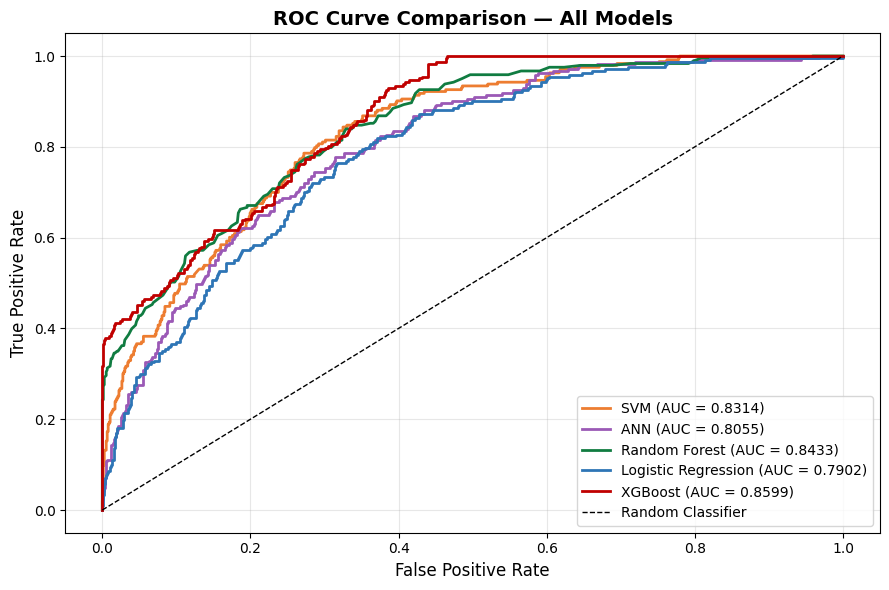

ROC curve saved.


In [13]:
# ============================================
# ROC Curve — All Models
# ============================================
plt.figure(figsize=(9, 6))
roc_models = [
    ("SVM",                 y_prob_svm,    "#ED7D31"),
    ("ANN",                 y_prob_ann,    "#9B59B6"),
    ("Random Forest",       y_prob_rf,     "#107C41"),
    ("Logistic Regression", y_prob_lr,     "#2E75B6"),
    ("XGBoost",             xgb_prob_test, "#C00000"),
]
for name, prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("result/roc_curve_comparison.png", dpi=150)
plt.show()
print("ROC curve saved.")

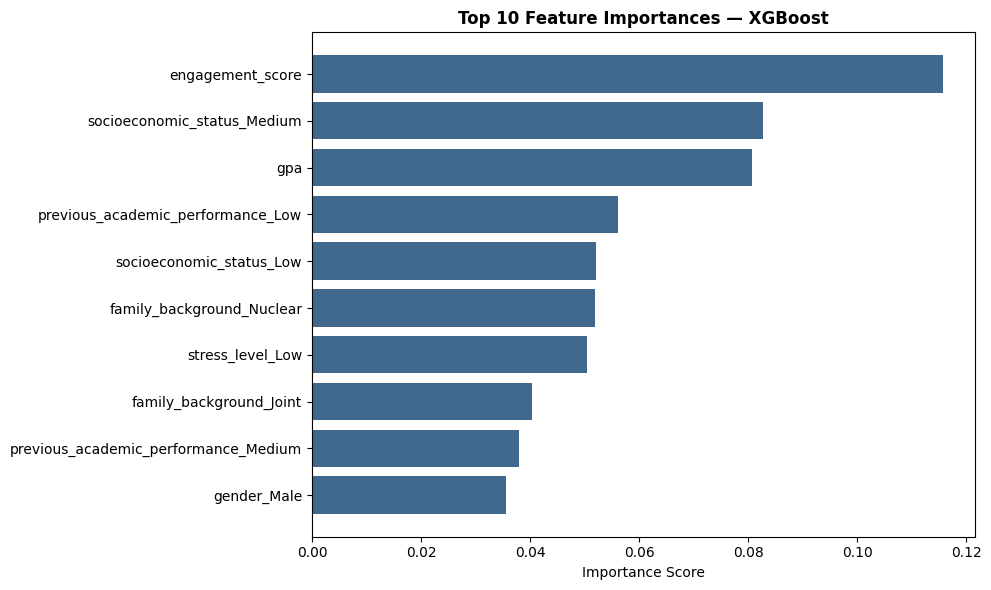

Feature importance plot saved.


In [14]:
# ============================================
# Feature Importance — XGBoost
# ============================================
plt.figure(figsize=(10, 6))
importances = xgb_model.feature_importances_
indices = importances.argsort()[::-1][:10]
plt.barh(
    range(10),
    importances[indices][::-1],
    color="#1F4E79", alpha=0.85
)
plt.yticks(range(10), X.columns[indices][::-1])
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig("result/feature_importance_plot.png", dpi=150)
plt.show()
print("Feature importance plot saved.")

In [15]:
# ============================================
# Export Results
# ============================================

# -- student_dropout_results.csv --
xgb_prob_full  = xgb_model.predict_proba(X)[:, 1]
xgb_pred_full  = (xgb_prob_full >= THRESHOLD).astype(int)

results_df = pd.DataFrame({
    "student_id":     df['student_id'],
    "actual_dropout": y,
    "xgboost_pred":   xgb_pred_full,
    "xgboost_prob":   xgb_prob_full
})
results_df.to_csv("result/student_dropout_results_updated.csv", index=False)
print(f"\nResults exported → student_dropout_results_updated.csv (threshold = {THRESHOLD})")

# -- feature_importance.csv --
fi_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)
fi_df.to_csv("result/feature_importance_updated.csv", index=False)
print("Feature importance exported → feature_importance_updated.csv")

# -- model_comparison.csv (for Power BI Page 5) --
comparison_df = pd.DataFrame({
    "Model":     ["XGBoost", "Random Forest", "ANN", "SVM", "Logistic Regression"],
    "CV_Accuracy": [
        round(xgb_acc.mean(), 4),
        round(rf_acc.mean(),  4),
        round(ann_acc.mean(), 4),
        round(svm_acc.mean(), 4),
        round(lr_acc.mean(),  4),
    ],
    "CV_F1": [
        round(xgb_f1.mean(), 4),
        round(rf_f1.mean(),  4),
        round(ann_f1.mean(), 4),
        round(svm_f1.mean(), 4),
        round(lr_f1.mean(),  4),
    ],
    "CV_AUC_ROC": [
        round(xgb_auc.mean(), 4),
        round(rf_auc.mean(),  4),
        round(ann_auc.mean(), 4),
        round(svm_auc.mean(), 4),
        round(lr_auc.mean(),  4),
    ],
    "Test_Accuracy": [
        round(accuracy_score(y_test, xgb_pred_tuned), 4),
        round(accuracy_score(y_test, y_pred_rf),      4),
        round(accuracy_score(y_test, y_pred_ann),     4),
        round(accuracy_score(y_test, y_pred_svm),     4),
        round(accuracy_score(y_test, y_pred_lr),      4),
    ],
    "Test_F1": [
        round(f1_score(y_test, xgb_pred_tuned), 4),
        round(f1_score(y_test, y_pred_rf),      4),
        round(f1_score(y_test, y_pred_ann),     4),
        round(f1_score(y_test, y_pred_svm),     4),
        round(f1_score(y_test, y_pred_lr),      4),
    ],
    "Test_AUC_ROC": [
        round(roc_auc_score(y_test, xgb_prob_test), 4),
        round(roc_auc_score(y_test, y_prob_rf),     4),
        round(roc_auc_score(y_test, y_prob_ann),    4),
        round(roc_auc_score(y_test, y_prob_svm),    4),
        round(roc_auc_score(y_test, y_prob_lr),     4),
    ],
    "Notes": [
        f"Threshold={THRESHOLD}, Final Model",
        "Default threshold",
        "early_stopping=True, max_iter=1000",
        "probability=True added",
        "Default threshold",
    ]
})


Results exported → student_dropout_results_updated.csv (threshold = 0.35)
Feature importance exported → feature_importance_updated.csv


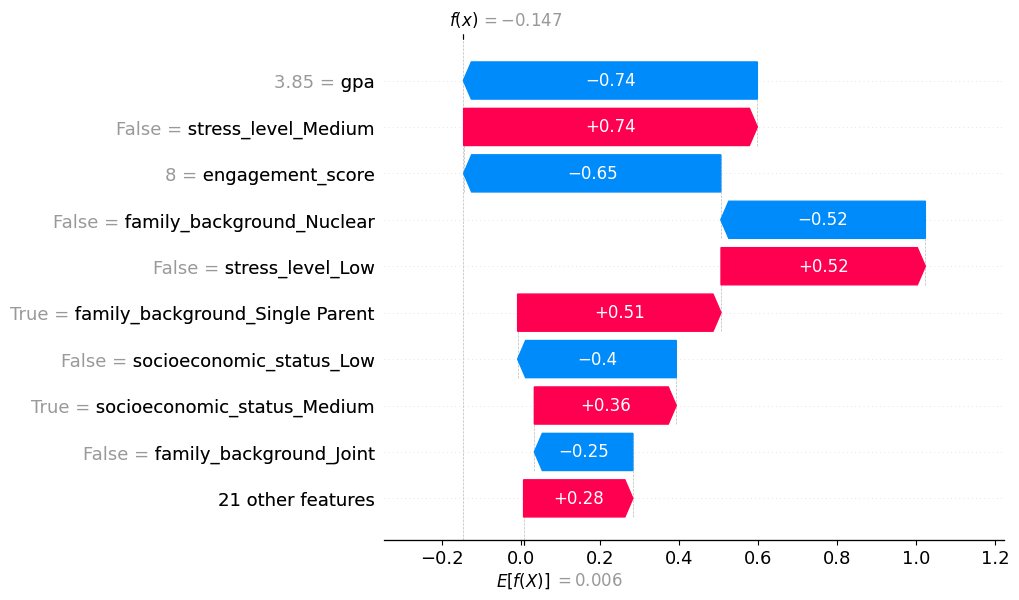

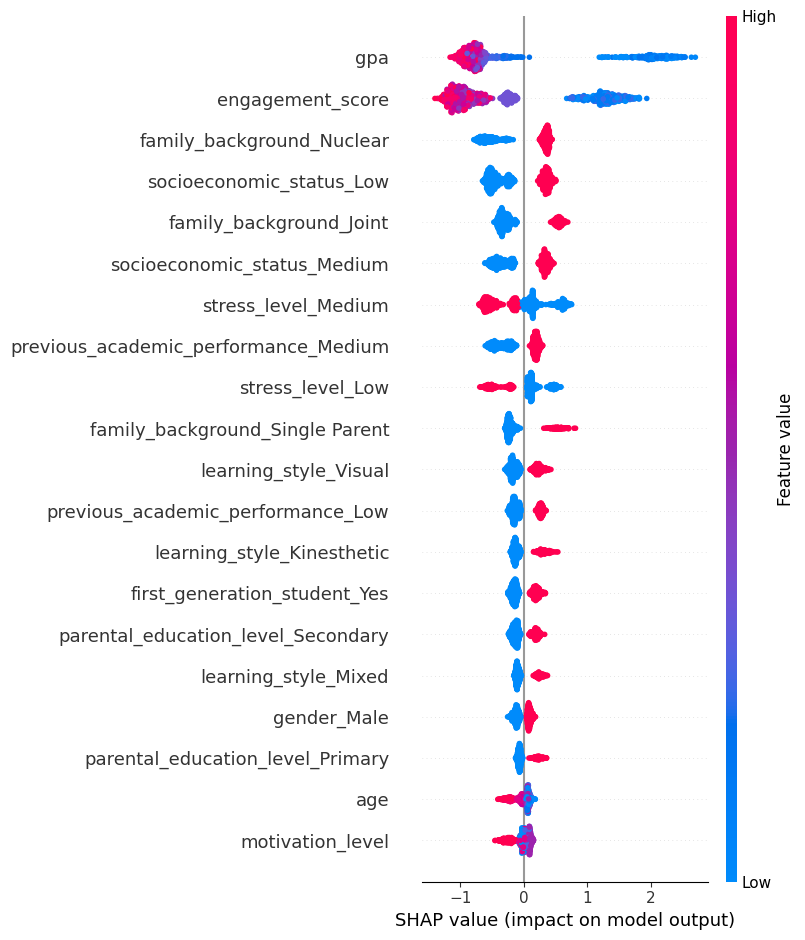

Model comparison exported → model_comparison.csv

All done!


In [16]:
import shap

# SHAP values show per-student feature contributions
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot for the single highest-risk student
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],           # first test student
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns.tolist()
    )
)
# Summary plot across all test students
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist())

comparison_df.to_csv("result/model_comparison.csv", index=False)
print("Model comparison exported → model_comparison.csv")
print("\nAll done!")